# Instalação

In [ ]:
# Install required packages.
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

2.0.1+cu118
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!cat /proc/cpuinfo
!df -h
!cat /proc/meminfo
!nvidia-smi
!nvidia-smi --query-gpu=memory.total

processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 85
model name	: Intel(R) Xeon(R) CPU @ 2.00GHz
stepping	: 3
microcode	: 0xffffffff
cpu MHz		: 2000.150
cache size	: 39424 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch invpcid_single ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm mpx avx512f avx512dq rdseed adx smap clflushopt clwb avx512cd avx512bw avx512vl xsaveopt xsavec xgetbv1 xsaves arat md_clear arch_capabilities
bugs		: cpu_meltdown spectre_v1 spectre_v2 spec_store_bypass l1tf mds swapgs taa mmi

In [ ]:
!pip install nvidia-ml-py3
!pip install ipython-autotime
%load_ext autotime

time: 398 µs (started: 2023-09-02 04:00:39 +00:00)


# Utils

In [ ]:
import psutil
import os
from torch_geometric.profile import get_cpu_memory_from_gc, get_stats_summary

pid = os.getpid()
process = psutil.Process(pid)

def print_memory_and_cpu():
  # Get the CPU usage as a percentage
  cpu_percent = psutil.cpu_percent()

  cpu_percent_per_core = psutil.cpu_percent(percpu=True)

  # Get the memory usage in bytes
  memory_bytes = process.memory_info().rss

  # Convert the memory usage to MB or GB (optional)
  memory_mb = memory_bytes / 1024 / 1024
  memory_gb = memory_bytes / 1024 / 1024 / 1024

  cpu_gc = get_cpu_memory_from_gc() / 1024 / 1024 / 1024
  # stats_summary = get_stats_summary(stats_list=)

  # Return the results
  return cpu_percent, memory_gb, cpu_gc, cpu_percent_per_core


time: 1.6 s (started: 2023-09-02 04:00:39 +00:00)


In [ ]:
import psutil

def print_psi():
  # Get the overall PSI va

  # Print the PSI values
  print("Overall PSI values: ", psi)

  # Iterate over all running processes and print their PSI values
  for proc in psutil.process_iter(['pid', 'name']):
      io_counters = proc.io_counters()
      if io_counters:
          print(f"Process {proc.pid} ({proc.info['name']}): {io_counters.psi}")

time: 513 µs (started: 2023-09-02 04:00:41 +00:00)


In [ ]:
import pynvml

def monitor_gpu():
    try:
        pynvml.nvmlInit()

        # Get the handle of the first GPU
        handle = pynvml.nvmlDeviceGetHandleByIndex(0)

        # Get the GPU name
        name = pynvml.nvmlDeviceGetName(handle)

        # Get the current GPU utilization
        utilization = pynvml.nvmlDeviceGetUtilizationRates(handle)
        gpu_utilization = utilization.gpu

        # Get the current GPU memory usage
        meminfo = pynvml.nvmlDeviceGetMemoryInfo(handle)
        gpu_used_memory = meminfo.used

        gpu_used_memory =  gpu_used_memory / (1024 * 1024 * 1024)

        pynvml.nvmlShutdown()
        return gpu_utilization, gpu_used_memory
    except:
      return 0,0

time: 4.57 ms (started: 2023-09-02 04:00:41 +00:00)


# Load Dataset

In [ ]:
from torch_geometric.datasets import Amazon
import torch_geometric.transforms as T

use_cuda_if_available = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = T.RandomNodeSplit()

dataset = Amazon(root="data/Amazon", name="Computers", transform=transform)

time: 61.2 ms (started: 2023-09-02 04:00:41 +00:00)


# Imports

In [ ]:
import torch
from tabulate import tabulate

time: 9.26 ms (started: 2023-09-02 04:00:41 +00:00)


In [ ]:
header = []
header.append(['Dataset', 'N. Graphs', 'N. Features', 'N. Classes', 'N. Nodes', 'N. Edges', 'Avg. Node Degree', 'N. Training Nodes', 'Training node label rate', 'Has isolated nodes', 'Has self-loops', 'Undirected'])
print()

data = dataset[0]  # Get the first graph object.
data = data.to(device)

print(f'data: {data}')
print(f'train mask: {data.train_mask}')

header.append([dataset, len(dataset), dataset.num_features, dataset.num_classes, data.num_nodes, data.num_edges,
               f'{data.num_edges / data.num_nodes:.2f}', data.train_mask.sum(), f'{int(data.train_mask.sum()) / data.num_nodes:.3f}',
               data.has_isolated_nodes(), data.has_self_loops(), data.is_undirected()])

print(tabulate(header, tablefmt="simple"))
# print(tabulate(header, tablefmt="latex"))


data: Data(x=[13752, 767], edge_index=[2, 491722], y=[13752], train_mask=[13752], val_mask=[13752], test_mask=[13752])
train mask: tensor([True, True, True,  ..., True, True, True], device='cuda:0')
-----------------  ---------  -----------  ----------  --------  --------  ----------------  -----------------  ------------------------  ------------------  --------------  ----------
Dataset            N. Graphs  N. Features  N. Classes  N. Nodes  N. Edges  Avg. Node Degree  N. Training Nodes  Training node label rate  Has isolated nodes  Has self-loops  Undirected
AmazonComputers()  1          767          10          13752     491722    35.76             12252              0.891                     True                False           True
-----------------  ---------  -----------  ----------  --------  --------  ----------------  -----------------  ------------------------  ------------------  --------------  ----------
time: 1.75 s (started: 2023-09-02 04:00:41 +00:00)


# Clustering Data

In [ ]:
from torch_geometric.loader import ClusterData, ClusterLoader

torch.manual_seed(12345)
cluster_data = ClusterData(data, num_parts=128)  # 1. Create subgraphs.
train_loader = ClusterLoader(cluster_data, batch_size=32, shuffle=True) # 2. Stochastic partioning scheme.

Computing METIS partitioning...


time: 540 ms (started: 2023-09-02 04:00:43 +00:00)


Done!


# GCN

In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = SAGEConv(dataset.num_node_features, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(hidden_channels=16)
model = model.to(device)
print(model)

GCN(
  (conv1): SAGEConv(767, 16, aggr=mean)
  (conv2): SAGEConv(16, 10, aggr=mean)
)
time: 7.18 ms (started: 2023-09-02 04:00:43 +00:00)


# Evaluate and Visualize

In [ ]:
cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
gpu_percent, gpu_memory = monitor_gpu()
print ('Before execution: \n')
print(cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core)
print(gpu_percent, gpu_memory)
print(torch.cuda.is_available())

Before execution: 

74.1 1.9956130981445312 0.046723317354917526 [71.2, 76.9]
1 0.98944091796875
True
time: 91.8 ms (started: 2023-09-02 04:00:43 +00:00)


In [ ]:
from IPython.display import Javascript
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
      model.train()
      # for sub_data in train_loader:  # Iterate over each mini-batch.
      out = model(data.x, data.edge_index)  # Perform a single forward pass.
      loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
      loss.backward()  # Derive gradients.
      optimizer.step()  # Update parameters based on gradients.
      optimizer.zero_grad()  # Clear gradients.

def test():
      model.eval()
      out = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)  # Use the class with highest probability.

      accs = []
      for mask in [data.train_mask, data.val_mask, data.test_mask]:
          correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
          accs.append(int(correct.sum()) / int(mask.sum()))  # Derive ratio of correct predictions.
      return accs
# print(f'Epoch\tTrain Acc\tVal Acc\tTest Acc\tCPU Percent\tMemory Use\tGarbage Collector')
results = []
results_formatted = []
results_formatted.append(['Epoch\t', 'TrainAcc.\t', 'ValAcc.\t', 'CPUPercent.\t', 'MemoryUse\t', 'GpuPercent.\t', 'GpuMem.\t\n'])

for epoch in range(1, 101):
    loss = train()
    train_acc, val_acc, test_acc = test()
    cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
    gpu_percent, gpu_memory = monitor_gpu()
    results.append([epoch, train_acc, test_acc, cpu_percent,memory_mb, cpu_gc, gpu_percent, gpu_memory])
    results_formatted.append([f'{epoch:03d}\t', f'{train_acc:.3f}\t', f'{test_acc:.3f}\t', f'{cpu_percent:.3f}\t', f'{memory_mb:.3f}\t', f'{gpu_percent:.3f}\t', f'{gpu_memory:.3f}\t\n'])
    print(f'{epoch:03d}')
print (results)

<IPython.core.display.Javascript object>

001
002
003
004
005
006
007
008
009
010
011
012
013
014
015
016
017
018
019
020
021
022
023
024
025
026
027
028
029
030
031
032
033
034
035
036
037
038
039
040
041
042
043
044
045
046
047
048
049
050
051
052
053
054
055
056
057
058
059
060
061
062
063
064
065
066
067
068
069
070
071
072
073
074
075
076
077
078
079
080
081
082
083
084
085
086
087
088
089
090
091
092
093
094
095
096
097
098
099
100
[[1, 0.10675808031341821, 0.093, 57.0, 2.5476303100585938, 0.04672333970665932, 26, 2.67694091796875], [2, 0.3700620306888671, 0.351, 58.3, 2.550159454345703, 0.04672333970665932, 47, 2.67889404296875], [3, 0.3690825987593862, 0.347, 60.0, 2.550159454345703, 0.04672333970665932, 43, 2.67889404296875], [4, 0.353656545870062, 0.335, 100.0, 2.550159454345703, 0.04672333970665932, 41, 2.67889404296875], [5, 0.23547175971269996, 0.248, 92.9, 2.550159454345703, 0.04672333970665932, 40, 2.67889404296875], [6, 0.15662748938948742, 0.157, 100.0, 2.550159454345703, 0.04672333970665932, 40, 2.67889404296

In [ ]:
cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
gpu_percent, gpu_memory = monitor_gpu()
print ('After execution: \n')
print(cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core, gpu_percent, gpu_memory)

After execution: 

57.9 2.5504112243652344 0.04672333970665932 [100.0, 20.0] 16 2.67889404296875
time: 81.7 ms (started: 2023-09-02 04:01:08 +00:00)


In [ ]:
def split_lattex(data_structure):
  # Split the data structure into header and rows
  header = data_structure[0]
  rows = data_structure[1:]

  set1_rows = rows[:40]
  set2_rows = rows[40:80]
  set3_rows = rows[80:]

  # Create three matrices with headers and rows
  matrix1 = [header] + set1_rows
  matrix2 = [header] + set2_rows
  matrix3 = [header] + set3_rows
  return matrix1, matrix2, matrix3

time: 730 µs (started: 2023-09-02 04:01:08 +00:00)


In [ ]:
from tabulate import tabulate

# print (results_formatted)
latex1, latex2, latex3 = split_lattex(results_formatted)


time: 524 µs (started: 2023-09-02 04:01:08 +00:00)


In [ ]:
print(tabulate(latex1, tablefmt="latex"))

\begin{tabular}{lllllll}
\hline
 Epoch & TrainAcc. & ValAcc. & CPUPercent. & MemoryUse & GpuPercent. & GpuMem. \\
 001   & 0.107     & 0.093   & 57.000      & 2.548     & 26.000      & 2.677   \\
 002   & 0.370     & 0.351   & 58.300      & 2.550     & 47.000      & 2.679   \\
 003   & 0.369     & 0.347   & 60.000      & 2.550     & 43.000      & 2.679   \\
 004   & 0.354     & 0.335   & 100.000     & 2.550     & 41.000      & 2.679   \\
 005   & 0.235     & 0.248   & 92.900      & 2.550     & 40.000      & 2.679   \\
 006   & 0.157     & 0.157   & 100.000     & 2.550     & 40.000      & 2.679   \\
 007   & 0.156     & 0.156   & 100.000     & 2.550     & 40.000      & 2.679   \\
 008   & 0.156     & 0.156   & 100.000     & 2.550     & 36.000      & 2.679   \\
 009   & 0.156     & 0.156   & 100.000     & 2.550     & 30.000      & 2.679   \\
 010   & 0.156     & 0.156   & 100.000     & 2.550     & 24.000      & 2.679   \\
 011   & 0.156     & 0.156   & 100.000     & 2.550     & 39.000   

In [ ]:
print(tabulate(latex2, tablefmt="latex"))

\begin{tabular}{lllllll}
\hline
 Epoch & TrainAcc. & ValAcc. & CPUPercent. & MemoryUse & GpuPercent. & GpuMem. \\
 041   & 0.156     & 0.156   & 100.000     & 2.550     & 0.000       & 2.679   \\
 042   & 0.156     & 0.156   & 100.000     & 2.550     & 40.000      & 2.679   \\
 043   & 0.156     & 0.156   & 100.000     & 2.550     & 40.000      & 2.679   \\
 044   & 0.156     & 0.156   & 100.000     & 2.550     & 40.000      & 2.679   \\
 045   & 0.156     & 0.156   & 100.000     & 2.550     & 25.000      & 2.679   \\
 046   & 0.156     & 0.156   & 100.000     & 2.550     & 40.000      & 2.679   \\
 047   & 0.156     & 0.156   & 100.000     & 2.550     & 40.000      & 2.679   \\
 048   & 0.156     & 0.156   & 100.000     & 2.550     & 40.000      & 2.679   \\
 049   & 0.156     & 0.156   & 100.000     & 2.550     & 27.000      & 2.679   \\
 050   & 0.156     & 0.156   & 100.000     & 2.550     & 41.000      & 2.679   \\
 051   & 0.156     & 0.156   & 100.000     & 2.550     & 0.000    

In [ ]:
print(tabulate(latex3, tablefmt="latex"))

\begin{tabular}{lllllll}
\hline
 Epoch & TrainAcc. & ValAcc. & CPUPercent. & MemoryUse & GpuPercent. & GpuMem. \\
 081   & 0.377     & 0.353   & 54.800      & 2.550     & 46.000      & 2.679   \\
 082   & 0.377     & 0.353   & 51.700      & 2.550     & 33.000      & 2.679   \\
 083   & 0.377     & 0.353   & 51.600      & 2.550     & 33.000      & 2.679   \\
 084   & 0.377     & 0.353   & 62.500      & 2.550     & 50.000      & 2.679   \\
 085   & 0.377     & 0.353   & 53.300      & 2.550     & 49.000      & 2.679   \\
 086   & 0.377     & 0.353   & 51.700      & 2.550     & 33.000      & 2.679   \\
 087   & 0.377     & 0.353   & 58.100      & 2.550     & 33.000      & 2.679   \\
 088   & 0.377     & 0.353   & 53.300      & 2.550     & 48.000      & 2.679   \\
 089   & 0.377     & 0.353   & 50.000      & 2.550     & 49.000      & 2.679   \\
 090   & 0.377     & 0.353   & 54.800      & 2.550     & 33.000      & 2.679   \\
 091   & 0.377     & 0.353   & 61.300      & 2.550     & 33.000   

In [ ]:
cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
print ('After execution: \n')
print(cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core)

After execution: 

65.6 2.5504112243652344 0.04672333970665932 [40.0, 86.7]
time: 86.3 ms (started: 2023-09-02 04:01:08 +00:00)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

epochs = [row[0] for row in results]
cpu_values = [row[3] for row in results]
mem_values = [row[4] for row in results]

gpu_values = [row[6] for row in results]
gpu_mem_values = [row[7] for row in results]


time: 1.05 s (started: 2023-09-02 04:01:08 +00:00)


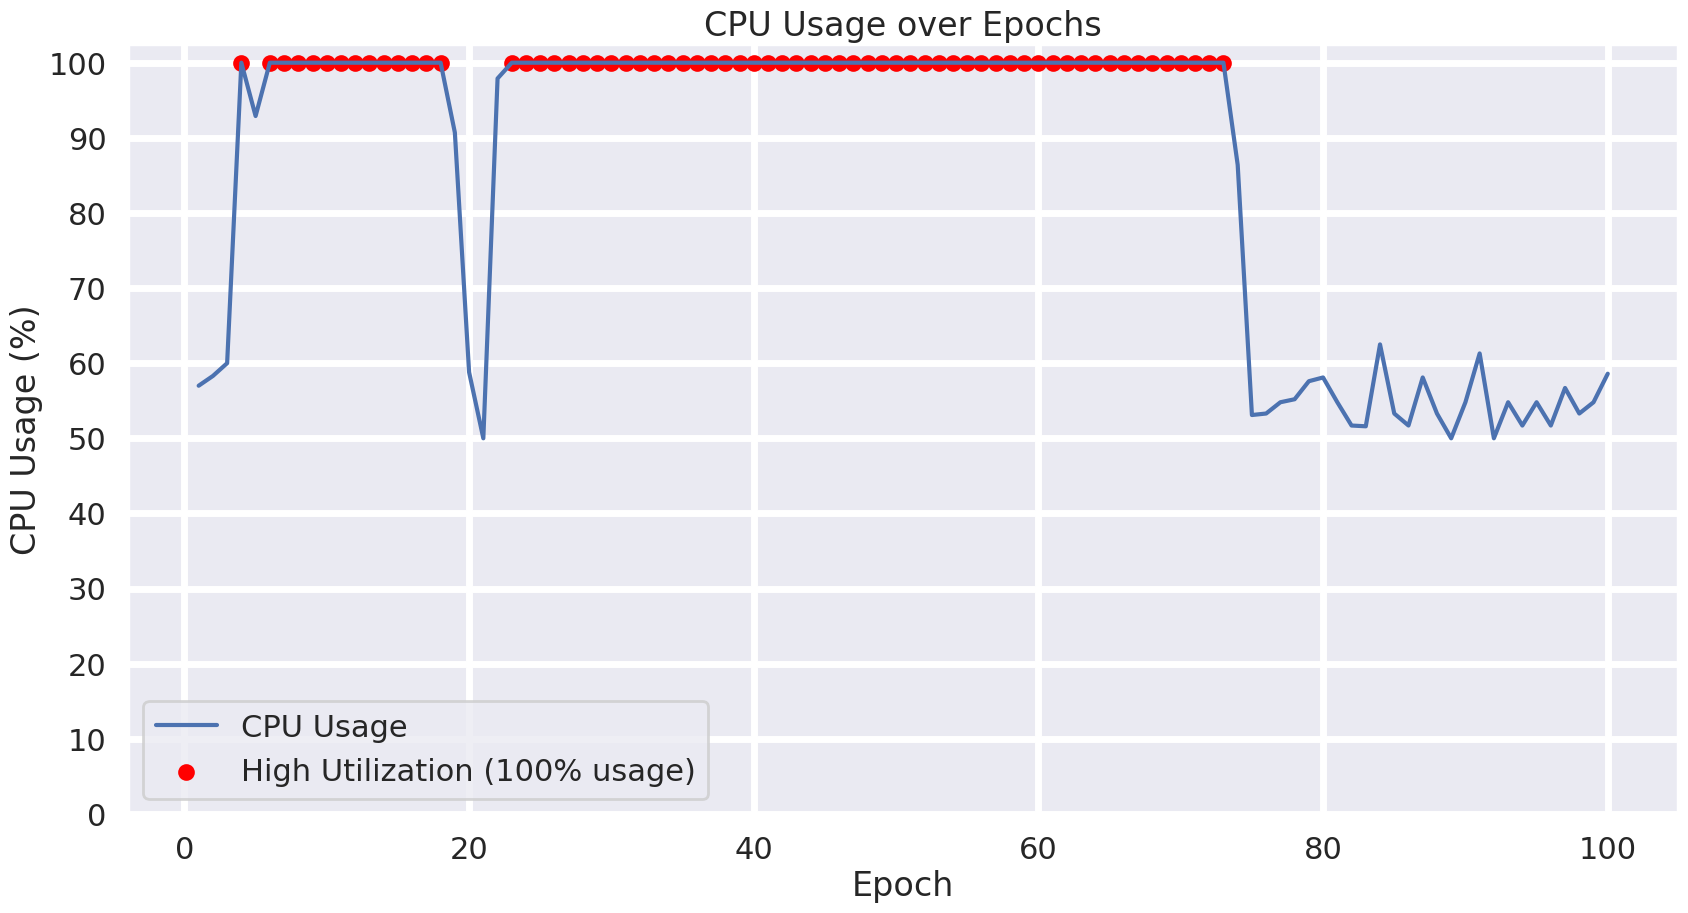

Percentage of High Utilization:  65.0
time: 445 ms (started: 2023-09-02 04:01:09 +00:00)


In [ ]:
# PLOT CPU USAGE

peak_indices, _ = find_peaks(cpu_values, height=100, plateau_size=1)

indices = [i for i in range(len(cpu_values)) if cpu_values[i] == 100.0]

plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, cpu_values, label='CPU Usage')
plt.scatter([epochs[i] for i in indices], [100]*len(indices), color='red', s=100, label='High Utilization (100% usage)')
# plt.scatter([epochs[i] for i in peak_indices], [100]*len(peak_indices), color='blue', s=100, label='Peak of Saturation')
plt.title('CPU Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('CPU Usage (%)')
plt.yticks(range(0, 101, 10))
plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

saturation = (len(indices) / len(epochs)) * 100
print('Percentage of High Utilization: ', saturation)

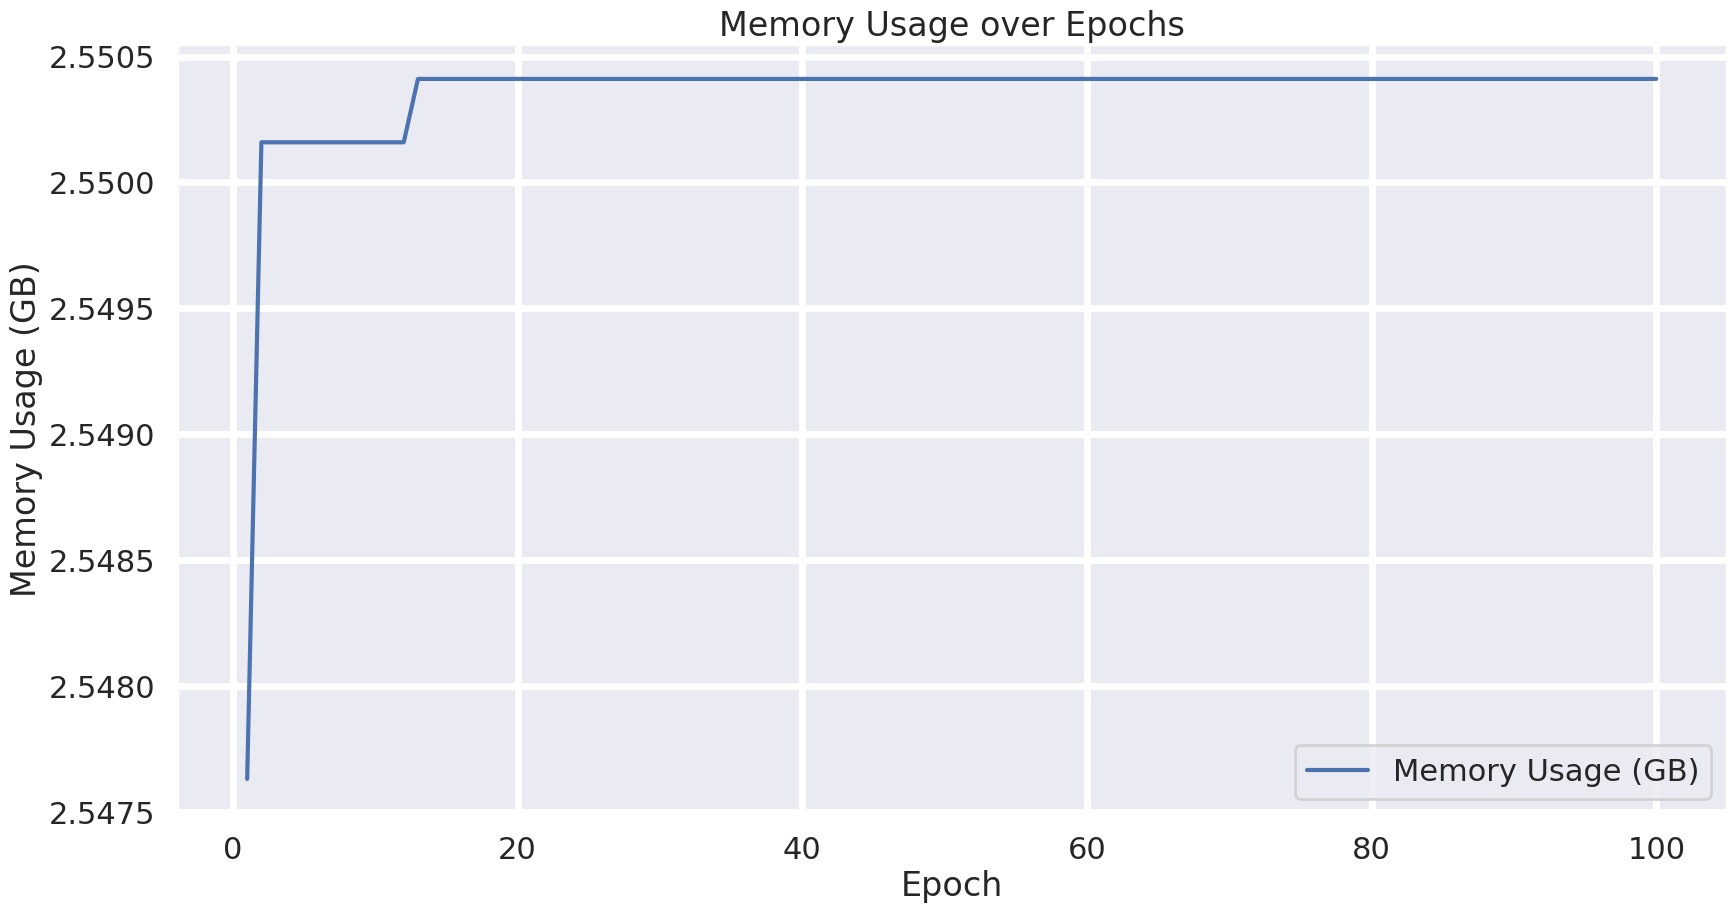

time: 380 ms (started: 2023-09-02 04:01:10 +00:00)


In [ ]:
# PLOT MEMORY USAGE
plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, mem_values, label='Memory Usage (GB)')
plt.title('Memory Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Memory Usage (GB)')
# plt.yticks(range(0, 101, 10))
# plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

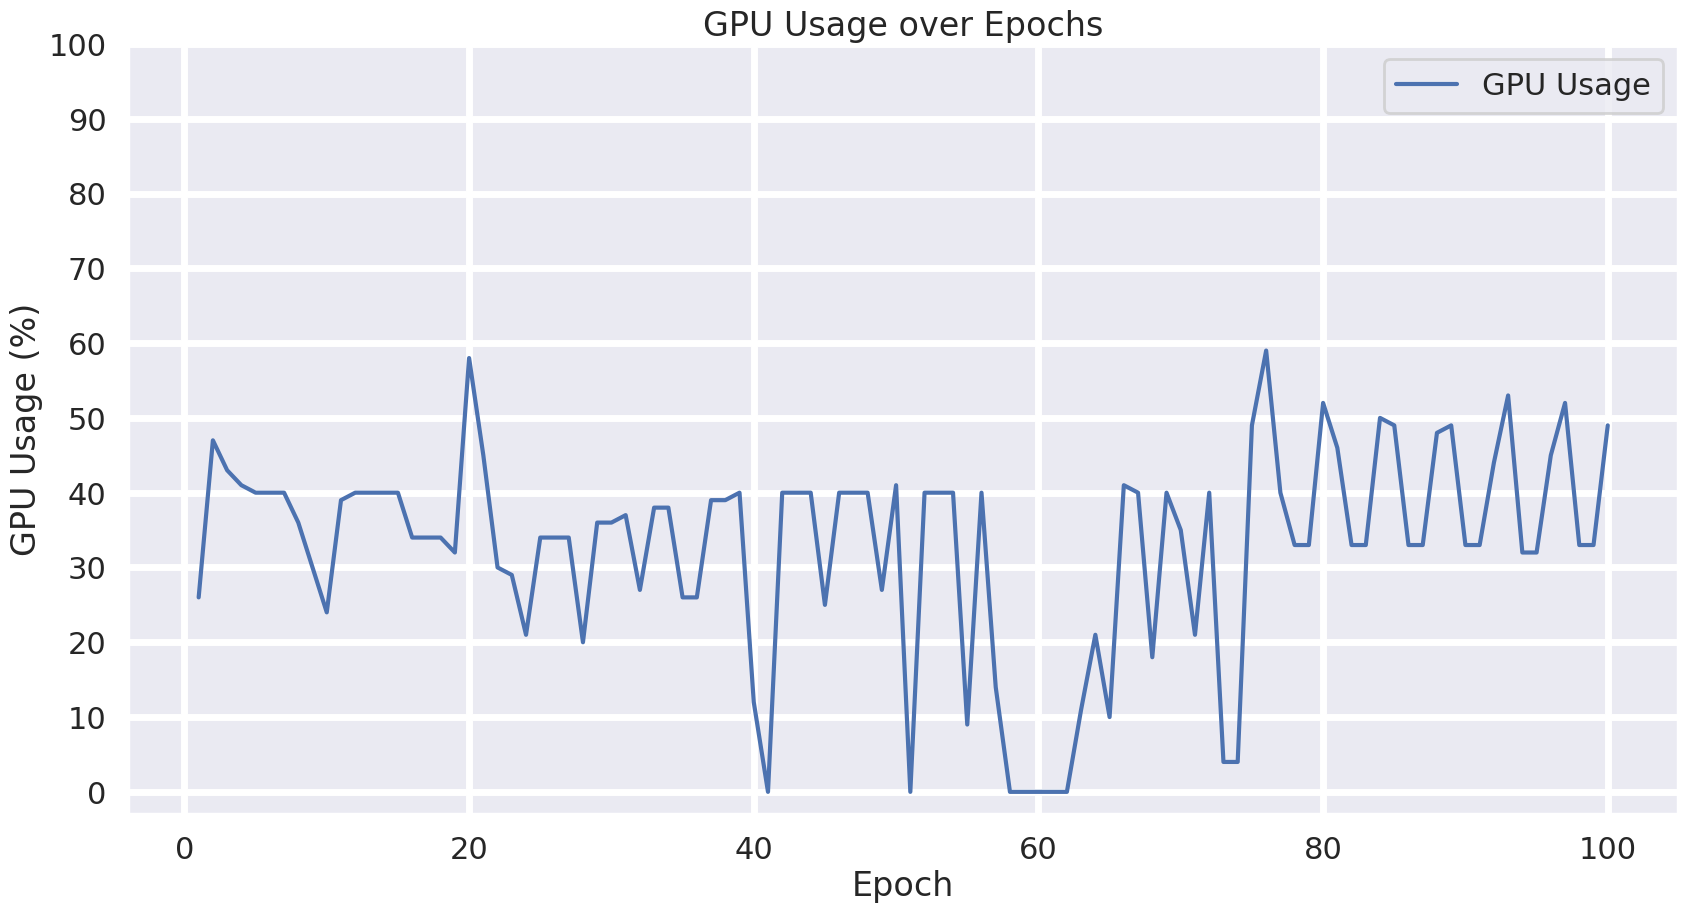

time: 385 ms (started: 2023-09-02 04:01:10 +00:00)


In [ ]:
# PLOT GPU USAGE
plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, gpu_values, label='GPU Usage')
plt.title('GPU Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('GPU Usage (%)')
plt.yticks(range(0, 101, 10))
plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

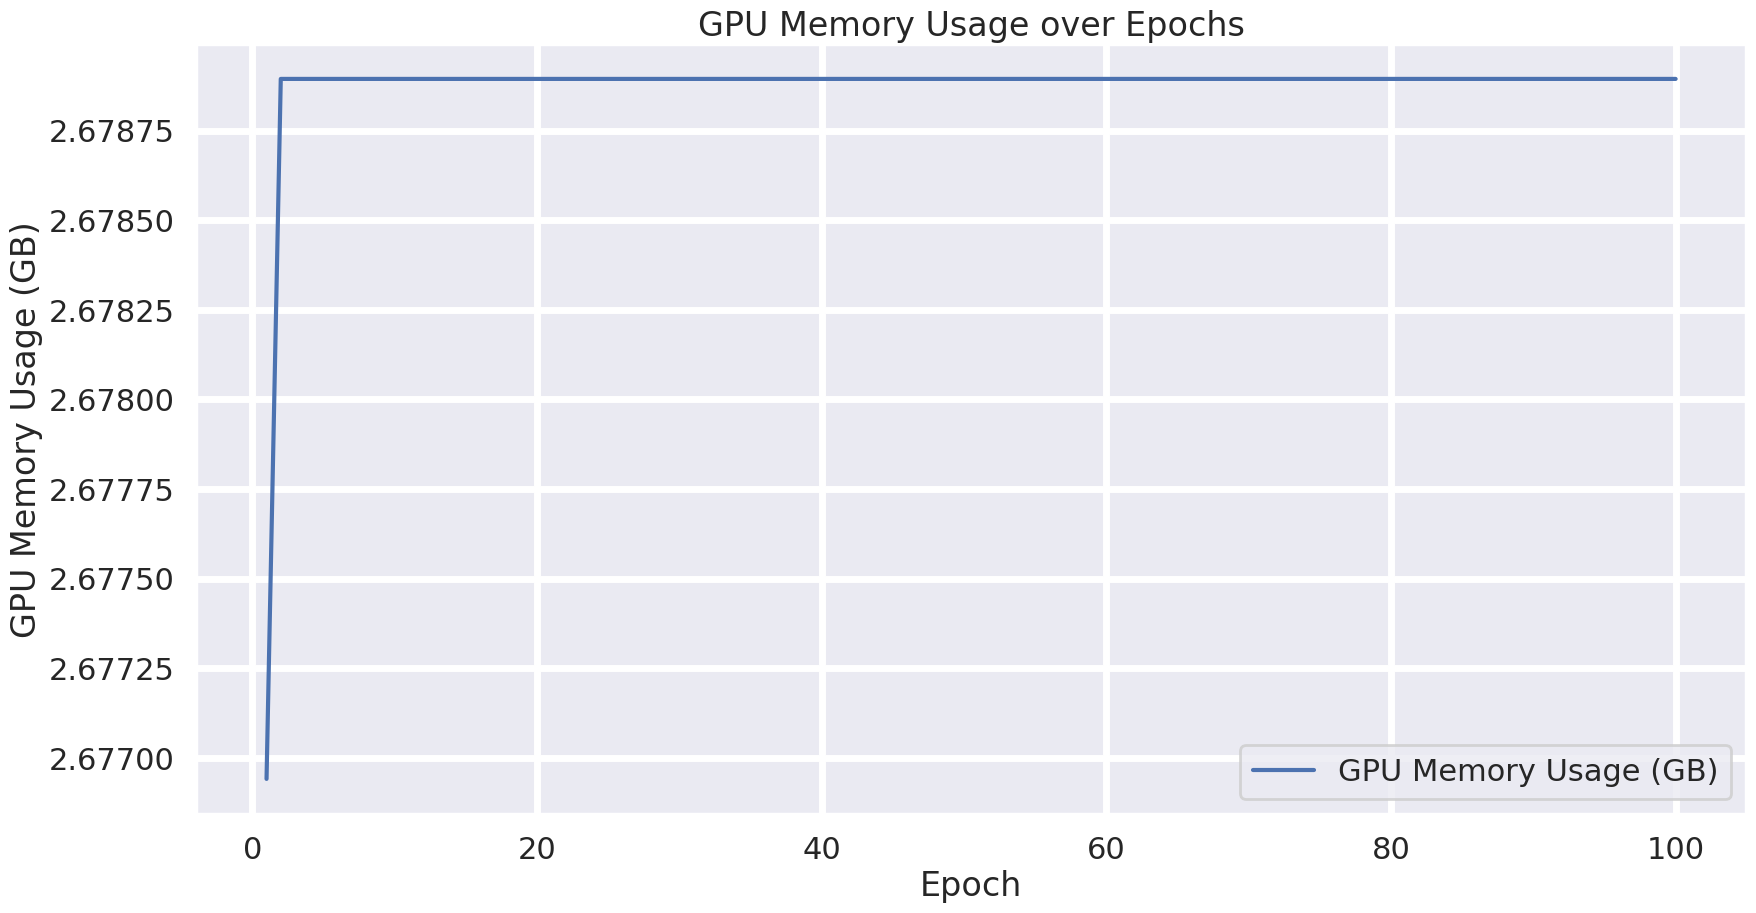

time: 399 ms (started: 2023-09-02 04:01:11 +00:00)


In [ ]:
# PLOT GPU MEMORY USAGE
plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, gpu_mem_values, label='GPU Memory Usage (GB)')
plt.title('GPU Memory Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('GPU Memory Usage (GB)')
# plt.yticks(range(0, 101, 10))
# plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

In [ ]:
psutil.cpu_stats()

scpustats(ctx_switches=2649807, interrupts=1990326, soft_interrupts=1328135, syscalls=0)

time: 4.27 ms (started: 2023-09-02 04:01:11 +00:00)
